In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Thesis/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""!pip install wrds"""

'!pip install wrds'

In [ ]:
import wrds
db = wrds.Connection(wrds_username='stevenli2002')
# !StOrZL20020226

Enter your WRDS username [stevenli2002]:stevenli2002
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

## Fundamental Data

In [ ]:
sp500 = pd.read_csv(path + 'sp500_constituents.csv')
num_patent = pd.read_csv(path + 'firm_quarter_with_ticker_only.csv')

tickers_union = list(set(sp500['Symbol']) | set(num_patent['ticker']))

In [ ]:
tickers_union_df = pd.DataFrame(tickers_union, columns=['Ticker'])

In [ ]:
tickers_union_df

,Ticker
0,GOOGL
1,EG
2,PLD
3,EL
4,EME
...,...
558,CCI
559,NFLX
560,OKE
561,BG


In [ ]:
ticker_str = ",".join([f"'{t}'" for t in tickers_union])
ticker_str

"'GOOGL','EG','PLD','EL','EME','MTD','GNRC','LH','MNST','ALRM','U','CPT','CVLT','POOL','IRBT','SNDK','ANET','TXT','ISRG','NWSA','SO','UPS','IR','RMD','APP','HOOD','CINF','XYL','SNN','HSY','CTSH','SJM','LIN','FRT','GOOG','PAYX','CRWD','ALGN','FIX','WM','PSA','SSTK','BMY','CAH','PFG','DUK','NUE','ARE','ROL','HIG','SONO','AZO','LYB','CME','TSLA','KVUE','CSCO','CF','AMP','KMB','VLO','ARES','AES','INTC','IT','DECK','TGT','AMCR','RCL','NOC','KO','PSKY','COP','MOS','AON','PG','SYK','PCAR','NTAP','STE','WMB','AMZN','ROKU','EOG','NDSN','RBRK','HSIC','KDP','DBX','STZ','IQV','INVH','JCI','HWM','SQ','TEAM','TRMB','NWS','BLK','HPE','CNC','SWK','NDAQ','RNG','ZBRA','REG','KR','BRK-B','EXC','LITE','AME','TTWO','WTW','FISV','LMT','ROK','HII','CVX','TAP','MAA','PFE','F','NSC','PANW','EXPE','JPM','MRK','CRM','LNT','LUV','ETN','MSFT','NTRS','PPG','EQT','VYX','GPC','MPWR','COO','CHTR','BX','PEG','CMI','SPG','DOV','CFG','IP','VST','WHR','FARO','HOLX','RSG','AIG','EQIX','SMCI','CDW','JKHY','BA','KEYS','MPC',

In [ ]:
query = f"""
    select
        a.gvkey,
        a.conm as companyname,
        a.tic as ticker,
        a.datadate,
        a.fyearq,
        a.fqtr,
        a.fyr,
        a.revtq as revenue,
        a.niq as netincome,
        a.xrdq as rnd,
        a.capxy as capex,
        a.atq as asset,
        a.teqq as equity,
        b.gsector as industry
    from comp.fundq as a
    left join comp.company as b
        on a.gvkey = b.gvkey
    where a.tic in ({ticker_str})
      and a.datadate >= '2016-01-01'
      and a.datadate < '2024-01-01'
      and a.indfmt = 'INDL'
      and a.datafmt = 'STD'
      and a.popsrc = 'D'
      and a.consol = 'C'
    order by a.tic, a.datadate
"""


fundq = db.raw_sql(query, date_cols=['datadate'])

fundq['calendar_q'] = (
    fundq['datadate'].dt.year.astype(str) + 'Q' +
    fundq['datadate'].dt.quarter.astype(str)
)

# Change unit from Million USD to USD
fundq['revenue'] = fundq['revenue'] * 1000000
fundq['netincome'] = fundq['netincome'] * 1000000
fundq['rnd'] = fundq['rnd'] * 1000000
fundq['capex'] = fundq['capex'] * 1000000
fundq['leverage'] = fundq['asset'] /  fundq['equity']

Fundamental_Data = fundq[
    ['companyname', 'ticker', 'gvkey', 'datadate', 'calendar_q', 'revenue', 'netincome', 'rnd', 'capex', 'leverage', 'industry']
].copy()

assert Fundamental_Data.duplicated(subset=['datadate', 'gvkey']).sum() == 0

In [ ]:
#Fundamental_Data[Fundamental_Data['ticker'] == 'NVDA']
#Fundamental_Data.to_csv(path + 'Company_Data/Fundamental_Data.csv', index=False)

In [ ]:
Fundamental_Data['ticker'].value_counts()

# GPN has a duplicated 2017Q1 and Q2 with no data. They will be drop in data cleaning

,count
ticker,
GPN,34
WAB,32
TER,32
ABBV,32
AKAM,32
...,...
SOUN,8
RBRK,7
SNDK,6


## Trading Data

In [ ]:
market_cap = pd.read_excel(path + 'Company_Data/MarketCap_Data.xlsx')
BM_ratio = pd.read_excel(path + 'Company_Data/BM_Data.xlsx')
return_data = pd.read_excel(path + 'Company_Data/Return_Data.xlsx')
volatility_data = pd.read_excel(path + 'Company_Data/Volatility_Data.xlsx')
ai_score_20162023 = pd.read_csv(path + 'company_quarter_ai_scores/company_quarter_ai_scores_llama_strict.csv')
ai_score_20242025 = pd.read_csv(path + 'company_quarter_ai_scores/company_quarter_ai_scores_llama_strict_20242025.csv')
ai_score_suppliment = pd.read_csv(path + 'company_quarter_ai_scores/company_quarter_ai_scores_target22_ticker.csv')
# We refined the logic of patent data matching and expanded our company list.
# We run separate scoring for the added companies.

Fundamental_Data = pd.read_csv(path + 'Company_Data/Fundamental_Data.csv')
Fundamental_Data['datadate'] = pd.to_datetime(Fundamental_Data['datadate'])

# Append rows
ai_score = pd.concat([ai_score_20162023, ai_score_20242025, ai_score_suppliment], ignore_index=True)

In [ ]:
Fundamental_Data

,companyname,ticker,gvkey,datadate,calendar_q,revenue,netincome,rnd,capex,leverage,industry
0,AGILENT TECHNOLOGIES INC,A,126554,2016-01-31,2016Q1,1.028000e+09,123000000.0,78000000.0,38000000.0,1.803854,35
1,AGILENT TECHNOLOGIES INC,A,126554,2016-04-30,2016Q2,1.019000e+09,91000000.0,81000000.0,63000000.0,1.834334,35
2,AGILENT TECHNOLOGIES INC,A,126554,2016-07-31,2016Q3,1.044000e+09,122000000.0,86000000.0,87000000.0,1.779567,35
3,AGILENT TECHNOLOGIES INC,A,126554,2016-10-31,2016Q4,1.111000e+09,126000000.0,84000000.0,139000000.0,1.837494,35
4,AGILENT TECHNOLOGIES INC,A,126554,2017-01-31,2017Q1,1.067000e+09,168000000.0,79000000.0,32000000.0,1.830698,35
...,...,...,...,...,...,...,...,...,...,...,...
17231,ZOETIS INC,ZTS,13721,2022-12-31,2022Q4,2.041000e+09,461000000.0,148000000.0,586000000.0,3.389734,35
17232,ZOETIS INC,ZTS,13721,2023-03-31,2023Q1,2.034000e+09,552000000.0,142000000.0,223000000.0,3.062570,35
17233,ZOETIS INC,ZTS,13721,2023-06-30,2023Q2,2.181000e+09,671000000.0,146000000.0,389000000.0,2.975330,35
17234,ZOETIS INC,ZTS,13721,2023-09-30,2023Q3,2.152000e+09,596000000.0,152000000.0,534000000.0,2.780055,35


In [ ]:
market_cap

,Unnamed: 0,2016-03-31 00:00:00,2016-06-30 00:00:00,2016-09-30 00:00:00,2016-12-30 00:00:00,2017-03-31 00:00:00,2017-06-30 00:00:00,2017-09-29 00:00:00,2017-12-29 00:00:00,2018-03-29 00:00:00,...,2023-12-29 00:00:00,2024-03-28 00:00:00,2024-06-28 00:00:00,2024-09-30 00:00:00,2024-12-31 00:00:00,2025-03-31 00:00:00,2025-06-30 00:00:00,2025-09-30 00:00:00,2025-12-31 00:00:00,2026-03-31 00:00:00
0,MMM,1.008175e+11,1.062128e+11,1.065135e+11,1.074039e+11,1.140709e+11,1.243393e+11,1.252614e+11,1.401883e+11,1.307242e+11,...,6.037930e+10,5.869503e+10,5.654799e+10,7.509664e+10,7.029707e+10,7.920429e+10,8.193273e+10,8.265348e+10,8.504913e+10,7.586760e+10
1,EGHT,8.898738e+08,1.305707e+09,1.383776e+09,1.294889e+09,1.386726e+09,1.333080e+09,1.239687e+09,1.296531e+09,1.718831e+09,...,4.617782e+08,3.332378e+08,2.783351e+08,2.617937e+08,3.488642e+08,2.633873e+08,2.647821e+08,2.891019e+08,2.731215e+08,2.312685e+08
2,AOS,6.699973e+09,7.713529e+09,8.619055e+09,8.234791e+09,8.863252e+09,9.747072e+09,1.025399e+10,1.053584e+10,1.090645e+10,...,1.226051e+10,1.315626e+10,1.199468e+10,1.310129e+10,9.890141e+09,9.409171e+09,9.318090e+09,1.028691e+10,9.312225e+09,9.118837e+09
3,ABT,6.162571e+10,5.775237e+10,6.216611e+10,5.655141e+10,7.674037e+10,8.435157e+10,9.270997e+10,9.933608e+10,1.046403e+11,...,1.910880e+11,1.972210e+11,1.807653e+11,1.983657e+11,1.961842e+11,2.300580e+11,2.366352e+11,2.331171e+11,2.178633e+11,1.784079e+11
4,ABBV,9.203393e+10,1.001307e+11,1.027122e+11,1.017637e+11,1.038598e+11,1.154026e+11,1.416513e+11,1.543907e+11,1.503016e+11,...,2.736053e+11,3.224348e+11,3.028816e+11,3.488176e+11,3.140208e+11,3.698772e+11,3.278797e+11,4.090289e+11,4.038297e+11,3.846881e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538,ZBRA,3.598294e+09,2.617192e+09,3.673103e+09,4.526904e+09,4.825049e+09,5.303808e+09,5.766493e+09,5.521029e+09,7.411872e+09,...,1.403812e+10,1.548841e+10,1.588500e+10,1.910124e+10,1.992124e+10,1.451771e+10,1.568144e+10,1.510915e+10,1.230132e+10,1.028500e+10
539,ZBH,2.120170e+10,2.398438e+10,2.600562e+10,2.067092e+10,2.455654e+10,2.589109e+10,2.367512e+10,2.443243e+10,2.215114e+10,...,2.543295e+10,2.711680e+10,2.232770e+10,2.198427e+10,2.102816e+10,2.252997e+10,1.804571e+10,1.951245e+10,1.782049e+10,1.769085e+10
540,ZTS,2.203890e+10,2.354976e+10,2.574722e+10,2.643486e+10,2.625612e+10,3.061591e+10,3.118576e+10,3.510425e+10,4.052354e+10,...,9.061527e+10,7.747569e+10,7.910332e+10,8.851710e+10,7.350832e+10,7.372894e+10,6.943020e+10,6.484661e+10,5.544802e+10,4.989972e+10
541,ZM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.189109e+10,2.010518e+10,1.830611e+10,2.146522e+10,2.501305e+10,2.251710e+10,2.359266e+10,2.469137e+10,2.555055e+10,2.368827e+10


In [ ]:
ai_score

,ticker,year,quarter,fiscal_period,total_blocks,total_words,candidate_blocks,ai_related_blocks,ai_adoption_related_blocks,ai_innovation_related_blocks,...,share_high_innovation_blocks,share_measurable_impact_innovation_blocks,share_product_innovation_blocks,share_process_innovation_blocks,share_technology_innovation_blocks,sum_adjusted_score,ai_adoption_score_mean,ai_related_candidate_blocks,high_adoption_candidate_blocks,measurable_impact_candidate_blocks
0,XRX,2016,1,2016Q1,14,8066,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
1,XRX,2016,2,2016Q2,22,7886,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
2,XRX,2016,3,2016Q3,23,7864,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
3,XRX,2016,4,2016Q4,21,7178,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
4,XRX,2017,1,2017Q1,16,9790,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20929,GEV,2024,4,2024Q4,14,7996,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
20930,GEV,2025,1,2025Q1,14,7787,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
20931,GEV,2025,2,2025Q2,15,8239,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
20932,GEV,2025,3,2025Q3,13,8024,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0


In [ ]:
# a helper function to clean trading data

def wide_to_long_quarter(df, value_name):
    df = df.copy()

    # first column is ticker
    first_col = df.columns[0]
    df = df.rename(columns={first_col: 'ticker'})
    df['ticker'] = df['ticker'].astype(str).str.upper().str.strip()

    # melt wide date columns into long format
    long_df = df.melt(
        id_vars='ticker',
        var_name='date',
        value_name=value_name
    )

    # parse dates
    long_df['date'] = pd.to_datetime(long_df['date'], errors='coerce')

    # convert to calendar quarter label like 2016Q1
    long_df['calendar_q'] = (
        long_df['date'].dt.year.astype('Int64').astype(str) +
        'Q' +
        long_df['date'].dt.quarter.astype('Int64').astype(str)
    )

    # keep needed columns
    long_df = long_df[['ticker', 'calendar_q', value_name]]

    return long_df

# -----------------------------
# 3. Convert trading data
# -----------------------------
mcap_long = wide_to_long_quarter(market_cap, 'market_cap')
bm_long   = wide_to_long_quarter(BM_ratio, 'bm_ratio')
ret_long  = wide_to_long_quarter(return_data, 'return_t')
vol_long = wide_to_long_quarter(volatility_data, 'vol_t')


In [ ]:
# -----------------------------
# 4. Merge trading vars at t
# -----------------------------
trading_t = mcap_long.merge(bm_long, on=['ticker', 'calendar_q'], how='outer')
trading_t = trading_t.merge(ret_long, on=['ticker', 'calendar_q'], how='outer')

# sort by ticker and quarter
trading_t['year'] = trading_t['calendar_q'].str[:4].astype(int)
trading_t['qtr'] = trading_t['calendar_q'].str[-1].astype(int)
trading_t = trading_t.sort_values(['ticker', 'year', 'qtr'])

# create forward return: t+1 (return data is t+1, the rest is t)
trading_t['return_t1'] = trading_t.groupby('ticker')['return_t'].shift(-1)
trading_t = trading_t[['ticker', 'calendar_q', 'market_cap', 'bm_ratio', 'return_t1']]

vol_long['year'] = vol_long['calendar_q'].str[:4].astype(int)
vol_long['qtr'] = vol_long['calendar_q'].str[-1].astype(int)

vol_long = vol_long.sort_values(['ticker', 'year', 'qtr'])

# create t+1 volatility
vol_long['vol_t1'] = vol_long.groupby('ticker')['vol_t'].shift(-1)

# keep only what we need
vol_long = vol_long[['ticker', 'calendar_q', 'vol_t1']]

In [ ]:
# -----------------------------
# 5. Prepare AI score
# -----------------------------
ai_cols = [
    'ticker',
    'fiscal_period',
    'ai_adoption_score_sum_norm_words',
    'ai_innovation_score_sum_norm_words'
]

ai_use = ai_score[ai_cols].copy()
ai_use['ticker'] = ai_use['ticker'].astype(str).str.upper().str.strip()
ai_use = ai_use.rename(columns={'fiscal_period': 'calendar_q'})
ai_use['calendar_q'] = ai_use['calendar_q'].astype(str).str.strip()

In [ ]:
# -----------------------------
# 6. Merge everything
# -----------------------------
merged = Fundamental_Data.merge(
    trading_t,
    on=['ticker', 'calendar_q'],
    how='left'
)

merged = merged.merge(
    ai_use,
    on=['ticker', 'calendar_q'],
    how='left'
)

merged = merged.merge(
    vol_long,
    on=['ticker', 'calendar_q'],
    how='left'
)


## Now Append the Number of AI Patents

In [ ]:
num_patent = pd.read_csv(path + 'firm_quarter_with_ticker_only.csv')

agg_num_patent = (
    num_patent
    .groupby(['ticker', 'quarter_str'])  # aggregate child and mother company
    .agg({
        'total_patents': 'sum',
        'ai_patents': 'sum'
    })
    .reset_index()
)

# recompute share after aggregation
agg_num_patent['ai_share'] = agg_num_patent['ai_patents'] / agg_num_patent['total_patents']
patent_use = agg_num_patent[['ticker', 'quarter_str', 'ai_patents', 'ai_share']].copy()

patent_use['ticker'] = patent_use['ticker'].astype(str).str.upper().str.strip()
patent_use['quarter_str'] = patent_use['quarter_str'].astype(str).str.strip()

patent_use = patent_use.rename(columns={'quarter_str': 'calendar_q'})

# -----------------------------
# 2. Merge into your main dataset
# -----------------------------
merged = merged.merge(
    patent_use,
    on=['ticker', 'calendar_q'],
    how='left'
)

# -----------------------------
# 3. Fill missing values with 0
# -----------------------------
merged['ai_patents'] = merged['ai_patents'].fillna(0)
merged['ai_share'] = merged['ai_share'].fillna(0)

In [ ]:
merged

,companyname,ticker,gvkey,datadate,calendar_q,revenue,netincome,rnd,capex,leverage,industry,market_cap,bm_ratio,return_t1,ai_adoption_score_sum_norm_words,ai_innovation_score_sum_norm_words,vol_t1,ai_patents,ai_share
0,AGILENT TECHNOLOGIES INC,A,126554,2016-01-31,2016Q1,1.028000e+09,123000000.0,78000000.0,38000000.0,1.803854,35,1.306164e+10,0.309686,0.111805,0.0,0.0,0.014027,0.0,0.0
1,AGILENT TECHNOLOGIES INC,A,126554,2016-04-30,2016Q2,1.019000e+09,91000000.0,81000000.0,63000000.0,1.834334,35,1.444014e+10,0.288224,0.081612,0.0,0.0,0.012845,0.0,0.0
2,AGILENT TECHNOLOGIES INC,A,126554,2016-07-31,2016Q3,1.044000e+09,122000000.0,86000000.0,87000000.0,1.779567,35,1.527528e+10,0.284316,-0.013027,0.0,0.0,0.014270,0.0,0.0
3,AGILENT TECHNOLOGIES INC,A,126554,2016-10-31,2016Q4,1.111000e+09,126000000.0,84000000.0,139000000.0,1.837494,35,1.465883e+10,0.289450,0.161289,0.0,0.0,0.011791,0.0,0.0
4,AGILENT TECHNOLOGIES INC,A,126554,2017-01-31,2017Q1,1.067000e+09,168000000.0,79000000.0,32000000.0,1.830698,35,1.704005e+10,0.252171,0.117585,0.0,0.0,0.010091,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17231,ZOETIS INC,ZTS,13721,2022-12-31,2022Q4,2.041000e+09,461000000.0,148000000.0,586000000.0,3.389734,35,6.830285e+10,0.068269,0.126096,0.0,0.0,0.016677,0.0,0.0
17232,ZOETIS INC,ZTS,13721,2023-03-31,2023Q1,2.034000e+09,552000000.0,142000000.0,223000000.0,3.062570,35,7.712609e+10,0.057114,0.051355,0.0,0.0,0.014604,0.0,0.0
17233,ZOETIS INC,ZTS,13721,2023-06-30,2023Q2,2.181000e+09,671000000.0,146000000.0,389000000.0,2.975330,35,7.958033e+10,0.056471,0.014503,0.0,0.0,0.015736,0.0,0.0
17234,ZOETIS INC,ZTS,13721,2023-09-30,2023Q3,2.152000e+09,596000000.0,152000000.0,534000000.0,2.780055,35,8.008594e+10,0.057750,0.136961,0.0,0.0,0.015414,0.0,0.0


In [ ]:
# Number of companies before data cleaning

len(merged['ticker'].unique())

553

## Data Cleaning

In [ ]:
df_clean = merged.copy()

# 1. drop key missing vars
df_clean = df_clean.dropna(subset=[
    'vol_t1',
    'return_t1',
    'market_cap',
    'bm_ratio',
    'netincome',
    'leverage',
    'ai_adoption_score_sum_norm_words',
    'ai_innovation_score_sum_norm_words'
])

# 2. handle variables where 0 is meaningful
df_clean['rnd'] = df_clean['rnd'].fillna(0)
df_clean['capex'] = df_clean['capex'].fillna(0)
df_clean['ai_patents'] = df_clean['ai_patents'].fillna(0)
df_clean['ai_share'] = df_clean['ai_share'].fillna(0)

# 3. revenue sanity filter
df_clean = df_clean[df_clean['revenue'] > 0] # exclude some banks

# 4. change  capex to quarterly
df_clean['capex_q'] = df_clean.groupby(['gvkey', df_clean['datadate'].dt.year])['capex'].diff()

# for Q1, diff = NaN → keep original
df_clean['capex_q'] = df_clean['capex_q'].fillna(df_clean['capex'])

In [ ]:
df_clean['ticker'].value_counts()

# The final company universe is 509

,count
ticker,
ZTS,32
A,32
AAPL,32
ABBV,32
ZBRA,32
...,...
TROW,3
KVUE,2
SCHW,2


In [ ]:
def winsorize_series(s, lower=0.01, upper=0.99):
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lower=lo, upper=hi)

In [ ]:
df_reg = df_clean.copy()

key_x = [
    'market_cap', 'bm_ratio', 'leverage',
    'revenue', 'netincome', 'capex_q'
]

ai_cols = [
    'ai_adoption_score_sum_norm_words',
    'ai_innovation_score_sum_norm_words'
]

winsor_cols = [
    'revenue', 'netincome', 'rnd', 'capex_q', 'leverage',
    'market_cap', 'bm_ratio', 'ai_patents', 'ai_share'
] + ai_cols

for col in winsor_cols:
    if col in df_reg.columns:
        df_reg[col] = df_reg.groupby('calendar_q')[col].transform(
            lambda x: winsorize_series(x, 0.01, 0.99)
        )

df_reg['log_revenue'] = np.log1p(df_reg['revenue'])
df_reg['log_mktcap']  = np.log(df_reg['market_cap'])
df_reg['log_rnd']     = np.log1p(df_reg['rnd'])
df_reg['log_capex']   = np.log1p(df_reg['capex_q'])
df_reg['log_ai_patents'] = np.log(1 + df_reg['ai_patents'])
df_reg['ai_score_composite'] = (df_reg['ai_adoption_score_sum_norm_words'] + df_reg['ai_innovation_score_sum_norm_words'])/2

# net income can be negative, so scale instead of log
df_reg['ni_margin'] = df_reg['netincome'] / df_reg['revenue']

# standardize within quarter (z-score)
# -----------------------------
z_cols = [
    'log_revenue', 'log_mktcap', 'log_rnd', 'log_capex', 'log_ai_patents',
    'ni_margin', 'bm_ratio', 'leverage', 'ai_share', 'ai_score_composite'
] + ai_cols

def zscore(s):
    std = s.std()
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std

for col in z_cols:
    if col in df_reg.columns:
        df_reg[f'z_{col}'] = df_reg.groupby('calendar_q')[col].transform(zscore)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# for return regression
return_vars = [
    'ticker', 'gvkey', 'calendar_q', 'industry', 'return_t1',
    'z_log_mktcap', 'z_bm_ratio', 'z_leverage', 'z_log_revenue',
    'z_ni_margin', 'z_log_rnd', 'z_log_capex', 'z_log_ai_patents',
    'z_ai_share',
    'z_ai_adoption_score_sum_norm_words',
    'z_ai_innovation_score_sum_norm_words',
    'z_ai_score_composite'
]
return_vars = [c for c in return_vars if c in df_reg.columns]
df_return = df_reg[return_vars].dropna()

# for volatility regression
vol_vars = [
    'ticker', 'gvkey', 'calendar_q', 'industry', 'vol_t1', 'log_vol_t1',
    'z_log_mktcap', 'z_bm_ratio', 'z_leverage', 'z_log_revenue',
    'z_ni_margin', 'z_log_rnd', 'z_log_capex', 'z_log_ai_patents',
    'z_ai_share',
    'z_ai_adoption_score_sum_norm_words',
    'z_ai_innovation_score_sum_norm_words',
    'z_ai_score_composite'
]
vol_vars = [c for c in vol_vars if c in df_reg.columns]
df_vol = df_reg[vol_vars].dropna()

## Panel Regression

In [ ]:
# -----------------------------
# 0. Make sure FE variables are strings
# -----------------------------
df_vol_reg = df_vol.copy()
df_return_reg = df_return.copy()

for df_ in [df_vol_reg, df_return_reg]:
    df_['calendar_q'] = df_['calendar_q'].astype(str)
    df_['industry'] = df_['industry'].astype(str)
    df_['gvkey'] = df_['gvkey'].astype(str)

# -----------------------------
# 1. Define controls and AI vars
# -----------------------------
control_vars = [
    'z_log_mktcap',
    'z_bm_ratio',
    'z_leverage',
    'z_log_revenue',
    'z_ni_margin',
    'z_log_rnd',
    'z_log_capex'
]

ai_vars = [
    'z_log_ai_patents',
    'z_ai_share',
    'z_ai_adoption_score_sum_norm_words',
    'z_ai_innovation_score_sum_norm_words',
    'z_ai_score_composite'
]

# keep only columns that actually exist
control_vars_vol = [x for x in control_vars if x in df_vol_reg.columns]
control_vars_ret = [x for x in control_vars if x in df_return_reg.columns]

ai_vars_vol = [x for x in ai_vars if x in df_vol_reg.columns]
ai_vars_ret = [x for x in ai_vars if x in df_return_reg.columns]

print("Vol controls:", control_vars_vol)
print("Vol AI vars:", ai_vars_vol)
print("Return controls:", control_vars_ret)
print("Return AI vars:", ai_vars_ret)

# -----------------------------
# 2. Helper functions
# -----------------------------
def add_stars(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    return ''

def make_table(model, keep_vars):
    out = pd.DataFrame({
        'coef': model.params,
        'std_err': model.bse,
        'p_value': model.pvalues
    })
    out = out.loc[[v for v in keep_vars if v in out.index]].copy()
    out['stars'] = out['p_value'].apply(add_stars)
    out['coef_fmt'] = out['coef'].map(lambda x: f"{x:.4f}") + out['stars']
    out['std_err_fmt'] = out['std_err'].map(lambda x: f"({x:.4f})")
    return out[['coef_fmt', 'std_err_fmt', 'p_value']]

def run_fe_regression(df, y_var, x_list):
    needed = [y_var] + x_list + ['calendar_q', 'industry', 'gvkey']
    reg_df = df.dropna(subset=needed).copy()

    formula = (
        f"{y_var} ~ " +
        " + ".join(x_list) +
        " + C(calendar_q) + C(industry)"
    )

    model = smf.ols(
        formula=formula,
        data=reg_df
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': reg_df['gvkey']}
    )

    return model, reg_df, formula


Vol controls: ['z_log_mktcap', 'z_bm_ratio', 'z_leverage', 'z_log_revenue', 'z_ni_margin', 'z_log_rnd', 'z_log_capex']
Vol AI vars: ['z_log_ai_patents', 'z_ai_share', 'z_ai_adoption_score_sum_norm_words', 'z_ai_innovation_score_sum_norm_words', 'z_ai_score_composite']
Return controls: ['z_log_mktcap', 'z_bm_ratio', 'z_leverage', 'z_log_revenue', 'z_ni_margin', 'z_log_rnd', 'z_log_capex']
Return AI vars: ['z_log_ai_patents', 'z_ai_share', 'z_ai_adoption_score_sum_norm_words', 'z_ai_innovation_score_sum_norm_words', 'z_ai_score_composite']


## Check Correlation

In [ ]:
df_corr = df_return_reg.copy()   # or df_vol_reg

# variables for correlation
corr_vars = [
    'z_log_mktcap',
    'z_bm_ratio',
    'z_leverage',
    'z_log_revenue',
    'z_ni_margin',
    'z_log_rnd',
    'z_log_capex',
    'z_log_ai_patents',
    'z_ai_share',
    'z_ai_adoption_score_sum_norm_words',
    'z_ai_innovation_score_sum_norm_words',
    'z_ai_score_composite'
]

# keep only existing columns
corr_vars = [v for v in corr_vars if v in df_corr.columns]

# drop missing
df_corr_clean = df_corr[corr_vars].dropna()

corr_matrix = df_corr_clean.corr()

print(corr_matrix.round(3))

                                      z_log_mktcap  z_bm_ratio  z_leverage  \
z_log_mktcap                                 1.000      -0.112       0.060   
z_bm_ratio                                  -0.112       1.000       0.046   
z_leverage                                   0.060       0.046       1.000   
z_log_revenue                                0.704       0.202       0.131   
z_ni_margin                                  0.191      -0.096      -0.028   
z_log_rnd                                    0.045      -0.245      -0.110   
z_log_capex                                  0.253      -0.133      -0.000   
z_log_ai_patents                             0.201      -0.081      -0.020   
z_ai_share                                   0.001      -0.154      -0.021   
z_ai_adoption_score_sum_norm_words           0.051      -0.109      -0.023   
z_ai_innovation_score_sum_norm_words         0.057      -0.098      -0.022   
z_ai_score_composite                         0.056      -0.110  

In [ ]:
# -----------------------------
# 4. Run SEPARATE models: one AI score at a time
# -----------------------------
vol_sep_results = {}
ret_sep_results = {}

print("\n" + "=" * 100)
print("SEPARATE VOL regressions: one AI score at a time")
print("=" * 100)

for ai in ai_vars_vol:
    x_vars = control_vars_vol + [ai]
    model, reg_df, formula = run_fe_regression(df_vol_reg, 'vol_t1', x_vars)
    table = make_table(model, x_vars)

    vol_sep_results[ai] = {
        'model': model,
        'data': reg_df,
        'formula': formula,
        'table': table
    }

    print(f"\nVOL model with {ai}")
    print("Sample size:", reg_df.shape)
    print("Formula:\n", formula)
    print(table)

print("\n" + "=" * 100)
print("SEPARATE RETURN regressions: one AI score at a time")
print("=" * 100)

for ai in ai_vars_ret:
    x_vars = control_vars_ret + [ai]
    model, reg_df, formula = run_fe_regression(df_return_reg, 'return_t1', x_vars)
    table = make_table(model, x_vars)

    ret_sep_results[ai] = {
        'model': model,
        'data': reg_df,
        'formula': formula,
        'table': table
    }

    print(f"\nRETURN model with {ai}")
    print("Sample size:", reg_df.shape)
    print("Formula:\n", formula)
    print(table)


SEPARATE VOL regressions: one AI score at a time

VOL model with z_log_ai_patents
Sample size: (14355, 17)
Formula:
 vol_t1 ~ z_log_mktcap + z_bm_ratio + z_leverage + z_log_revenue + z_ni_margin + z_log_rnd + z_log_capex + z_log_ai_patents + C(calendar_q) + C(industry)
                    coef_fmt std_err_fmt       p_value
z_log_mktcap      -0.0017***    (0.0004)  1.282829e-06
z_bm_ratio            0.0001    (0.0002)  5.958201e-01
z_leverage          0.0003**    (0.0001)  1.376384e-02
z_log_revenue      -0.0008**    (0.0003)  2.626815e-02
z_ni_margin       -0.0016***    (0.0002)  2.099351e-26
z_log_rnd          0.0009***    (0.0003)  1.471525e-03
z_log_capex           0.0000    (0.0002)  8.559133e-01
z_log_ai_patents     0.0005*    (0.0003)  5.441112e-02

VOL model with z_ai_share
Sample size: (14355, 17)
Formula:
 vol_t1 ~ z_log_mktcap + z_bm_ratio + z_leverage + z_log_revenue + z_ni_margin + z_log_rnd + z_log_capex + z_ai_share + C(calendar_q) + C(industry)
                 coef_fmt

In [ ]:
# -----------------------------
# 5. Run JOINT patent models: z_log_ai_patents + z_ai_share together
# -----------------------------
joint_patent_vars = ['z_log_ai_patents', 'z_ai_share']

joint_patent_vars_vol = [x for x in joint_patent_vars if x in df_vol_reg.columns]
joint_patent_vars_ret = [x for x in joint_patent_vars if x in df_return_reg.columns]

vol_joint_result = None
ret_joint_result = None

print("\n" + "=" * 100)
print("JOINT VOL regression: z_log_ai_patents + z_ai_share")
print("=" * 100)

if len(joint_patent_vars_vol) == 2:
    x_vars = control_vars_vol + joint_patent_vars_vol
    model, reg_df, formula = run_fe_regression(df_vol_reg, 'vol_t1', x_vars)
    table = make_table(model, x_vars)

    vol_joint_result = {
        'model': model,
        'data': reg_df,
        'formula': formula,
        'table': table
    }

    print("VOL joint model with z_log_ai_patents and z_ai_share")
    print("Sample size:", reg_df.shape)
    print("Formula:\n", formula)
    print(table)

print("\n" + "=" * 100)
print("JOINT RETURN regression: z_log_ai_patents + z_ai_share")
print("=" * 100)

if len(joint_patent_vars_ret) == 2:
    x_vars = control_vars_ret + joint_patent_vars_ret
    model, reg_df, formula = run_fe_regression(df_return_reg, 'return_t1', x_vars)
    table = make_table(model, x_vars)

    ret_joint_result = {
        'model': model,
        'data': reg_df,
        'formula': formula,
        'table': table
    }

    print("RETURN joint model with z_log_ai_patents and z_ai_share")
    print("Sample size:", reg_df.shape)
    print("Formula:\n", formula)
    print(table)


JOINT VOL regression: z_log_ai_patents + z_ai_share
VOL joint model with z_log_ai_patents and z_ai_share
Sample size: (14355, 17)
Formula:
 vol_t1 ~ z_log_mktcap + z_bm_ratio + z_leverage + z_log_revenue + z_ni_margin + z_log_rnd + z_log_capex + z_log_ai_patents + z_ai_share + C(calendar_q) + C(industry)
                    coef_fmt std_err_fmt       p_value
z_log_mktcap      -0.0017***    (0.0004)  1.385677e-06
z_bm_ratio            0.0002    (0.0002)  4.315963e-01
z_leverage          0.0003**    (0.0001)  1.668199e-02
z_log_revenue       -0.0007*    (0.0003)  5.141482e-02
z_ni_margin       -0.0016***    (0.0001)  3.861089e-26
z_log_rnd          0.0009***    (0.0003)  1.360935e-03
z_log_capex           0.0001    (0.0002)  6.926557e-01
z_log_ai_patents      0.0001    (0.0003)  8.729613e-01
z_ai_share           0.0006*    (0.0003)  5.911381e-02

JOINT RETURN regression: z_log_ai_patents + z_ai_share
RETURN joint model with z_log_ai_patents and z_ai_share
Sample size: (14355, 17)
Formul

## Portfolio Sort

In [ ]:
df_port = df_clean.copy()

df_port['ai_score_composite'] = (df_port['ai_adoption_score_sum_norm_words'] + df_port['ai_innovation_score_sum_norm_words'])/2

ai_var = 'ai_score_composite'

df_port = df_port[['ticker', 'calendar_q', ai_var, 'return_t1', 'market_cap']].dropna().copy()

### AI vs Non- AI

In [ ]:
df_ai_non_ai = df_port.copy()

df_ai_non_ai['ai_dummy'] = (df_ai_non_ai['ai_score_composite'] > 0).astype(int)

# -----------------------------
# Equal-weight portfolio
# -----------------------------
ew = df_ai_non_ai.groupby(['calendar_q', 'ai_dummy'])['return_t1'].mean().unstack()
ew['AI_minus_NonAI'] = ew[1] - ew[0]

ew_mean = ew['AI_minus_NonAI'].mean()
ew_t = ew_mean / (ew['AI_minus_NonAI'].std() / np.sqrt(len(ew)))

# -----------------------------
# Value-weight portfolio
# -----------------------------
vw = df_ai_non_ai.groupby(['calendar_q', 'ai_dummy']).apply(
    lambda x: np.average(x['return_t1'], weights=x['market_cap'])
).unstack()

vw['AI_minus_NonAI'] = vw[1] - vw[0]

vw_mean = vw['AI_minus_NonAI'].mean()
vw_t = vw_mean / (vw['AI_minus_NonAI'].std() / np.sqrt(len(vw)))

def nw_test(series, lags=4):
    y = series.dropna()
    X = np.ones(len(y))

    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': lags}
    )

    alpha = model.params[0]
    tstat = model.tvalues[0]
    pval = model.pvalues[0]

    return {
        'alpha': alpha,
        't_stat': tstat,
        'p_value': pval
    }

"""ew_mean, ew_t = nw_test(ew['AI_minus_NonAI'])
vw_mean, vw_t = nw_test(vw['AI_minus_NonAI'])
"""
print("===== Newey-West Results =====")
print("EW HML:", nw_test(ew['AI_minus_NonAI']))
print("VW HML:", nw_test(vw['AI_minus_NonAI']))

===== Newey-West Results =====
EW HML: {'alpha': np.float64(0.017209202365156412), 't_stat': np.float64(1.956347064233092), 'p_value': np.float64(0.05042428349932951)}
VW HML: {'alpha': np.float64(0.016583773013284862), 't_stat': np.float64(1.2539105959745125), 'p_value': np.float64(0.2098745032340843)}


/tmp/ipykernel_111128/1973801566.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vw = df_ai_non_ai.groupby(['calendar_q', 'ai_dummy']).apply(
/tmp/ipykernel_111128/1973801566.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/tmp/ipykernel_111128/1973801566.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser

### Fama French


In [ ]:
df_ff5 = pd.read_excel(path + 'F-F_Research_Data_5_Factors_2x3.xlsx')

ff = df_ff5.copy()

# rename date column
ff = ff.rename(columns={'Unnamed: 0': 'date'})

# convert to datetime
ff['date'] = pd.to_datetime(ff['date'].astype(str), format='%Y%m')

# convert percent → decimal
cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff[cols] = ff[cols] / 100

ff['calendar_q'] = ff['date'].dt.to_period('Q').astype(str)

ff_q = (
    ff.groupby('calendar_q')[cols]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
)

In [ ]:
def run_ff5(port_df, ff_q, port_name, ret_col='HML_AI'):
    # prepare portfolio data
    port = port_df.copy().reset_index()

    # merge with FF5
    df_reg = port.merge(ff_q, on='calendar_q', how='inner').dropna().copy()

    # dependent variable: H-L portfolio return
    y = df_reg[ret_col] - df_reg['RF']

    # FF5 regressors
    X = df_reg[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
    X = sm.add_constant(X)

    # Newey-West / HAC standard errors
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

    # clean output table
    out = pd.DataFrame({
        'coef': model.params,
        'std_err': model.bse,
        'pval': model.pvalues
    })

    out['stars'] = out['pval'].apply(add_stars)
    out['coef_fmt'] = out['coef'].map(lambda x: f"{x:.4f}") + out['stars']
    out['se_fmt'] = out['std_err'].map(lambda x: f"({x:.4f})")

    print("\n" + "=" * 100)
    print(f"{port_name} FF5 regression")
    print("=" * 100)
    print("Sample size:", df_reg.shape[0])
    print(out[['coef_fmt', 'se_fmt', 'pval']])

    return model, df_reg, out

In [ ]:
model_AInonAI_ew, df_reg_AInonAI_ew, out_AInonAI_ew = run_ff5(ew, ff_q, "Equal-weighted", 'AI_minus_NonAI')
model_AInonAI_vw, df_reg_AInonAI_vw, out_AInonAI_vw = run_ff5(vw, ff_q, "Value-weighted", 'AI_minus_NonAI')


Equal-weighted FF5 regression
Sample size: 32
       coef_fmt    se_fmt      pval
const    0.0113  (0.0083)  0.176789
Mkt-RF   0.0685  (0.1230)  0.577877
SMB     -0.1846  (0.1603)  0.249594
HML     -0.0597  (0.1226)  0.626403
RMW     -0.0420  (0.1975)  0.831812
CMA      0.1940  (0.2633)  0.461200

Value-weighted FF5 regression
Sample size: 32
       coef_fmt    se_fmt      pval
const    0.0083  (0.0102)  0.419034
Mkt-RF   0.1022  (0.1582)  0.518367
SMB      0.0428  (0.2016)  0.831951
HML      0.0361  (0.2695)  0.893530
RMW      0.1210  (0.3045)  0.691145
CMA     -0.0288  (0.4884)  0.953049


### High AI - Low AI

In [ ]:
df_ai = df_port[df_port[ai_var] > 0].copy()

# assign AI tertile each quarter
df_ai['ai_tertile'] = df_ai.groupby('calendar_q')[ai_var].transform(
    lambda x: pd.qcut(x, 3, labels=False, duplicates='drop') + 1
)

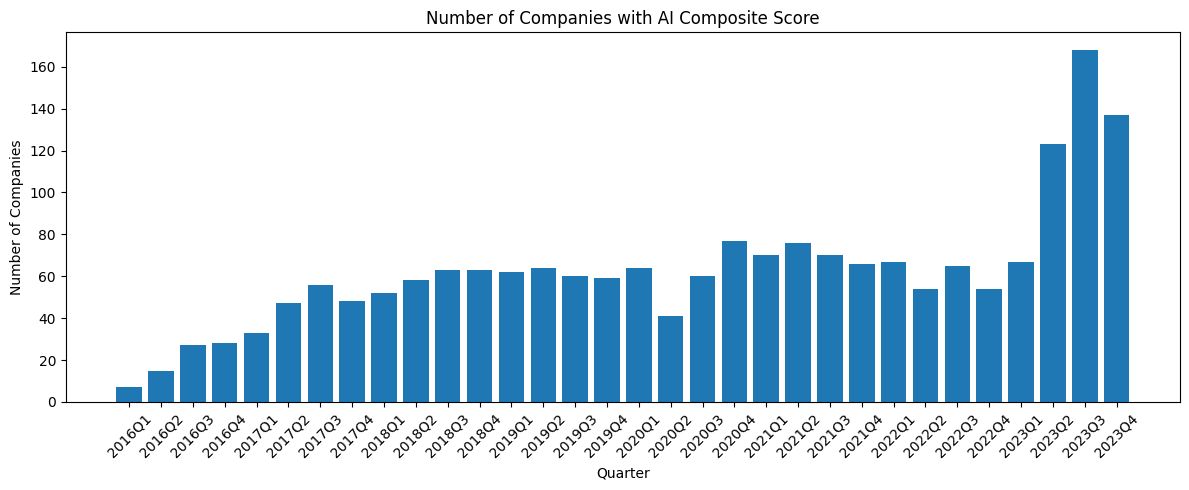

In [ ]:
# Count number of companies with AI Composite Score by quarter
company_count = (
    df_ai
    .groupby('calendar_q')
    .size()
    .reset_index(name='num_companies')
)

# Sort quarters correctly
company_count['quarter'] = pd.PeriodIndex(company_count['calendar_q'], freq='Q')
company_count = company_count.sort_values('quarter')

# Plot
plt.figure(figsize=(12, 5))

plt.bar(
    company_count['quarter'].astype(str),
    company_count['num_companies']
)

plt.xlabel('Quarter')
plt.ylabel('Number of Companies')
plt.title('Number of Companies with AI Composite Score')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [ ]:
# Equal-weighted returns
port_ret_ew = (
    df_ai.groupby(['calendar_q', 'ai_tertile'])['return_t1']
    .mean()
    .reset_index()
)

# reshape
port_ew = port_ret_ew.pivot(index='calendar_q', columns='ai_tertile', values='return_t1')
port_ew.columns = ['Low_AI', 'Mid_AI', 'High_AI']

# High minus Low
port_ew['HML_AI'] = port_ew['High_AI'] - port_ew['Low_AI']

# sort time
port_ew = port_ew.sort_index()

port_ew.head()

,Low_AI,Mid_AI,High_AI,HML_AI
calendar_q,,,,
2016Q1,0.011731,0.090024,0.125476,0.113744
2016Q2,0.131289,0.185097,0.201309,0.070019
2016Q3,0.048095,-0.024429,-0.021891,-0.069986
2016Q4,0.149353,0.095700,0.088526,-0.060827
2017Q1,0.005679,0.077907,0.088038,0.082359


In [ ]:
# Value-weighted returns
def vw_return(group):
    return np.average(group['return_t1'], weights=group['market_cap'])

port_ret_vw = (
    df_ai.groupby(['calendar_q', 'ai_tertile'])
    .apply(vw_return)
    .reset_index(name='return_t1')
)

# reshape
port_vw = port_ret_vw.pivot(index='calendar_q', columns='ai_tertile', values='return_t1')
port_vw.columns = ['Low_AI', 'Mid_AI', 'High_AI']

# High minus Low
port_vw['HML_AI'] = port_vw['High_AI'] - port_vw['Low_AI']

# sort time
port_vw = port_vw.sort_index()

/tmp/ipykernel_111128/428135954.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(vw_return)


In [ ]:
print("Equal-weighted mean returns:")
print(port_ew.mean())

print("\nValue-weighted mean returns:")
print(port_vw.mean())

Equal-weighted mean returns:
Low_AI     0.052471
Mid_AI     0.057633
High_AI    0.079624
HML_AI     0.027153
dtype: float64

Value-weighted mean returns:
Low_AI     0.030071
Mid_AI     0.042014
High_AI    0.074512
HML_AI     0.044440
dtype: float64


In [ ]:
print("===== Newey-West Results =====")
print("EW HML:", nw_test(port_ew['HML_AI']))
print("VW HML:", nw_test(port_vw['HML_AI']))

===== Newey-West Results =====
EW HML: {'alpha': np.float64(0.02715288688448312), 't_stat': np.float64(1.7823825850576238), 'p_value': np.float64(0.07468686345696605)}
VW HML: {'alpha': np.float64(0.04444048143083625), 't_stat': np.float64(2.685516085173356), 'p_value': np.float64(0.007241788889937502)}


/tmp/ipykernel_111128/1973801566.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/tmp/ipykernel_111128/1973801566.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tstat = model.tvalues[0]
/tmp/ipykernel_111128/1973801566.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = model.pvalues[0]
/tmp/ipykernel_111128/1973801566.py:35: FutureWarning: Series.__getitem__ treating keys as positions is d

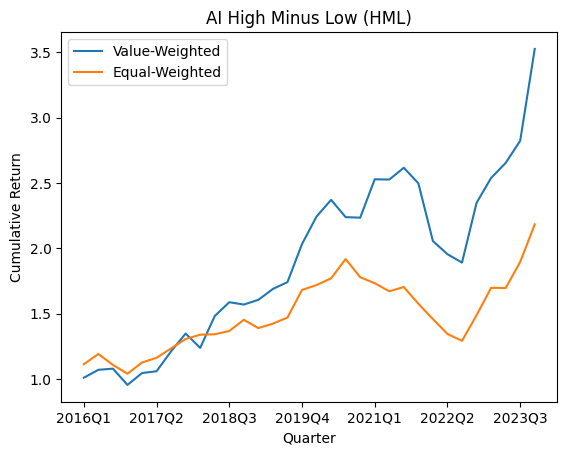

In [ ]:
# Compute cumulative returns
cum_hml_vw = (1 + port_vw['HML_AI']).cumprod()
cum_hml_ew = (1 + port_ew['HML_AI']).cumprod()

# Plot both
plt.figure()
cum_hml_vw.plot(label='Value-Weighted')
cum_hml_ew.plot(label='Equal-Weighted')

plt.title('AI High Minus Low (HML)')
plt.xlabel('Quarter')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [ ]:
model_ew, df_reg_ew, out_ew = run_ff5(port_ew, ff_q, "Equal-weighted")
model_vw, df_reg_vw, out_vw = run_ff5(port_vw, ff_q, "Value-weighted")


Equal-weighted FF5 regression
Sample size: 32
          coef_fmt    se_fmt      pval
const       0.0161  (0.0107)  0.132517
Mkt-RF    0.2860**  (0.1308)  0.028776
SMB     -0.6359***  (0.2260)  0.004898
HML         0.0129  (0.2671)  0.961540
RMW        -0.1795  (0.2660)  0.499798
CMA        -0.0051  (0.4009)  0.989762

Value-weighted FF5 regression
Sample size: 32
        coef_fmt    se_fmt      pval
const   0.0335**  (0.0154)  0.029546
Mkt-RF    0.2522  (0.2221)  0.256014
SMB       0.1525  (0.4370)  0.727054
HML      -0.3577  (0.4242)  0.399118
RMW      -0.1228  (0.5300)  0.816783
CMA       0.3979  (0.6669)  0.550691


### Separate the Effect of Industry: Neutral Portfolio within Each Industry

In [ ]:
industry_map = merged[['ticker', 'calendar_q', 'industry']]

df_industry_effect = pd.merge(df_ai, industry_map, on=['ticker', 'calendar_q'], how='left')

In [ ]:
df_industry_effect

,ticker,calendar_q,ai_score_composite,return_t1,market_cap,ai_tertile,industry
0,A,2022Q1,0.624477,-0.121833,3.971400e+10,2,35
1,AAPL,2016Q3,0.319465,0.037749,6.091635e+11,1,45
2,AAPL,2016Q4,0.062127,0.236039,6.175885e+11,1,45
3,AAPL,2017Q3,1.409177,0.108027,7.960649e+11,3,45
4,AAPL,2017Q4,0.797303,-0.015291,8.688796e+11,2,45
...,...,...,...,...,...,...,...
1996,ZS,2023Q3,1.659989,0.468063,2.289799e+10,3,45
1997,ZS,2023Q4,0.702983,-0.141731,3.286476e+10,2,45
1998,ZTS,2020Q3,0.312386,0.019862,7.857468e+10,1,35
1999,ZTS,2020Q4,0.853803,-0.039849,7.865682e+10,3,35


In [ ]:
# assign AI tertile each quarter
df_industry_effect['ai_tertile_industry'] = df_industry_effect.groupby(['calendar_q', 'industry'])[ai_var].transform(
    lambda x: pd.qcut(x, 3, labels=False, duplicates='drop') + 1
)

In [ ]:
# We need at least 3 companies in one industry

valid_groups = (
    df_industry_effect.groupby(['calendar_q', 'industry'])['ticker']
    .count()
    .reset_index(name='n')
)
valid_groups = valid_groups[valid_groups['n'] >= 3]

valid_groups

,calendar_q,industry,n
1,2016Q1,45,6
4,2016Q2,45,10
7,2016Q3,25,7
8,2016Q3,40,4
9,2016Q3,45,14
...,...,...,...
252,2023Q4,35,14
253,2023Q4,40,14
254,2023Q4,45,65
255,2023Q4,50,7


In [ ]:
df_industry_effect = df_industry_effect.merge(valid_groups[['calendar_q', 'industry']],
                    on=['calendar_q', 'industry'],
                    how='inner')
df_industry_effect

,ticker,calendar_q,ai_score_composite,return_t1,market_cap,ai_tertile,industry,ai_tertile_industry
0,A,2022Q1,0.624477,-0.121833,3.971400e+10,2,35,3.0
1,AAPL,2016Q3,0.319465,0.037749,6.091635e+11,1,45,1.0
2,AAPL,2016Q4,0.062127,0.236039,6.175885e+11,1,45,1.0
3,AAPL,2017Q3,1.409177,0.108027,7.960649e+11,3,45,3.0
4,AAPL,2017Q4,0.797303,-0.015291,8.688796e+11,2,45,2.0
...,...,...,...,...,...,...,...,...
1883,ZS,2023Q3,1.659989,0.468063,2.289799e+10,3,45,2.0
1884,ZS,2023Q4,0.702983,-0.141731,3.286476e+10,2,45,1.0
1885,ZTS,2020Q3,0.312386,0.019862,7.857468e+10,1,35,1.0
1886,ZTS,2020Q4,0.853803,-0.039849,7.865682e+10,3,35,3.0


In [ ]:
# -----------------------------
# 0. Start from industry-neutral panel
# -----------------------------
df_ind = df_industry_effect.copy()

# keep only rows with usable tertile assignment
df_ind = df_ind.dropna(subset=['ai_tertile_industry', 'return_t1', 'market_cap']).copy()
df_ind['ai_tertile_industry'] = df_ind['ai_tertile_industry'].astype(int)

# keep only low and high tertiles
df_ind = df_ind[df_ind['ai_tertile_industry'].isin([1,2, 3])].copy()

# -----------------------------
# 1. Equal-weighted within industry
# -----------------------------
ind_ew = (
    df_ind.groupby(['calendar_q', 'industry', 'ai_tertile_industry'])['return_t1']
    .mean()
    .unstack('ai_tertile_industry')
)

# rename columns if all tertiles exist
ind_ew = ind_ew.rename(columns={1: 'Low', 2: 'Mid',3: 'High'})

# keep only groups where all exist
ind_ew = ind_ew.dropna(subset=['Low', 'Mid', 'High']).copy()

# within-industry H-L
ind_ew['HML_AI_ind'] = ind_ew['High'] - ind_ew['Low']

# aggregate equally across industries each quarter
port_ind_ew = (
    ind_ew.groupby('calendar_q')[['Low', 'Mid', 'High', 'HML_AI_ind']]
    .mean()
    .sort_index()
)

# -----------------------------
# 2. Value-weighted within industry
# -----------------------------
def weighted_ret(g):
    return np.average(g['return_t1'], weights=g['market_cap'])

ind_vw = (
    df_ind.groupby(['calendar_q', 'industry', 'ai_tertile_industry'])
    .apply(weighted_ret)
    .unstack('ai_tertile_industry')
)

ind_vw = ind_vw.rename(columns={1: 'Low', 2: 'Mid', 3: 'High'})
ind_vw = ind_vw.dropna(subset=['Low','Mid', 'High']).copy()
ind_vw['HML_AI_ind'] = ind_vw['High'] - ind_vw['Low']

# industry total market cap at t, for weighting industries across quarter
ind_mktcap = (
    df_ind.groupby(['calendar_q', 'industry'])['market_cap']
    .sum()
    .rename('ind_mktcap')
)

ind_vw = ind_vw.merge(ind_mktcap, left_index=True, right_index=True, how='left')

# aggregate across industries using industry market cap weights
def weighted_avg_cols(g, col):
    return np.average(g[col], weights=g['ind_mktcap'])

port_ind_vw = (
    ind_vw.groupby(level=0)
    .apply(lambda g: pd.Series({
        'Low': weighted_avg_cols(g, 'Low'),
        'Mid': weighted_avg_cols(g, 'Mid'),
        'High': weighted_avg_cols(g, 'High'),
        'HML_AI_ind': weighted_avg_cols(g, 'HML_AI_ind')
    }))
    .sort_index()
)

/tmp/ipykernel_111128/3436840042.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_ret)


In [ ]:
ind_vw

Low       Mid      High  HML_AI_ind    ind_mktcap
calendar_q industry                                                        
2016Q1     45       -0.075007 -0.039851  0.243089    0.318097  6.532927e+11
2016Q2     45        0.076008  0.146407  0.104938    0.028930  6.114688e+11
2016Q3     25       -0.004662 -0.004698 -0.072399   -0.067737  5.978803e+11
           40        0.170962  0.060174  0.022722   -0.148240  8.653591e+10
           45        0.049104 -0.073282  0.115700    0.066595  1.578413e+12
...                       ...       ...       ...         ...           ...
2023Q4     35        0.003383  0.077540 -0.011991   -0.015374  1.381450e+12
           40        0.115423  0.066383  0.011865   -0.103559  1.121784e+12
           45       -0.041203  0.088253  0.257038    0.298242  1.144149e+13
           50       -0.050697  0.155690  0.351547    0.402244  1.041971e+12
           60       -0.072064  0.047666  0.045699    0.117763  3.093756e+11

[166 rows x 5 columns]

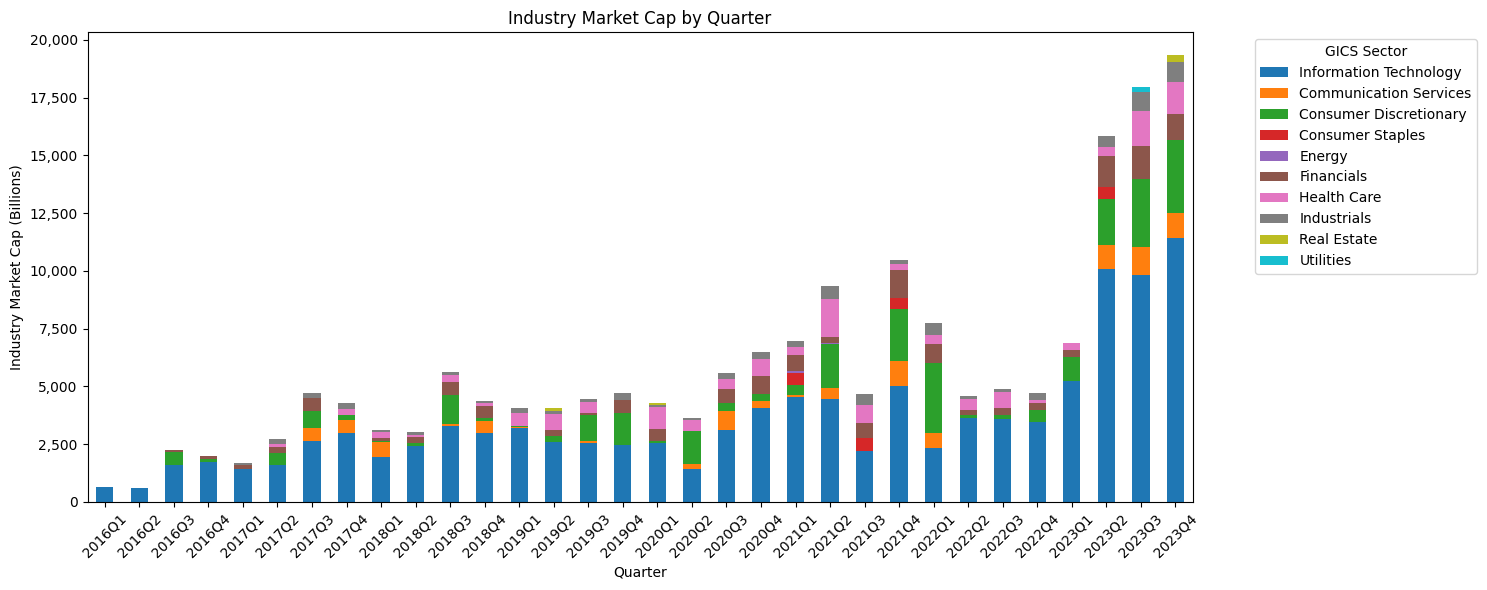

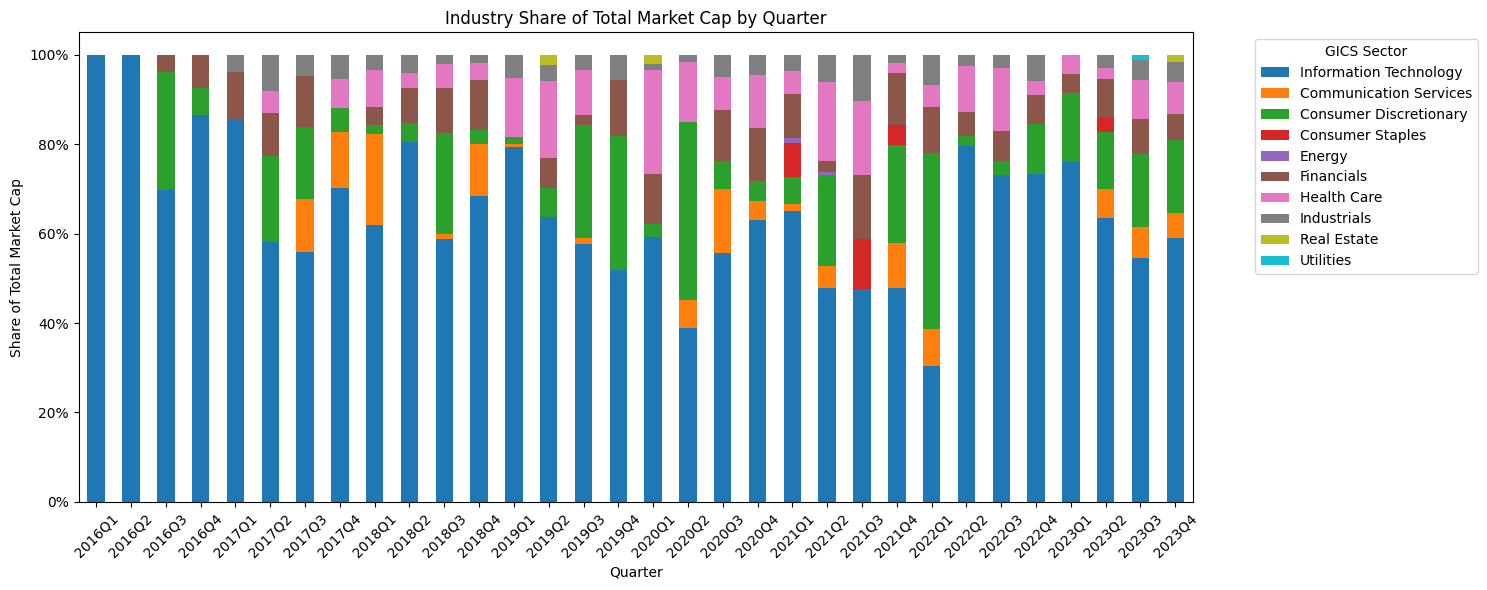

In [ ]:
# GICS sector mapping
gics_map = {
    10: 'Energy',
    15: 'Materials',
    20: 'Industrials',
    25: 'Consumer Discretionary',
    30: 'Consumer Staples',
    35: 'Health Care',
    40: 'Financials',
    45: 'Information Technology',
    50: 'Communication Services',
    55: 'Utilities',
    60: 'Real Estate'
}

# Prepare data
plot_df = ind_vw.reset_index()

plot_df['industry_name'] = plot_df['industry'].map(gics_map)

# Clean quarter labels: 2016Q1, 2016Q2, ...
plot_df['quarter_label'] = pd.PeriodIndex(
    plot_df['calendar_q'],
    freq='Q'
).astype(str)

# Pivot: rows = quarter, columns = GICS sector, values = market cap
mktcap_df = (
    plot_df
    .pivot(index='quarter_label', columns='industry_name', values='ind_mktcap')
    .fillna(0)
)

# Sort quarters correctly
mktcap_df = mktcap_df.sort_index()

# Put Information Technology at the bottom of the stack
cols = ['Information Technology'] + [
    c for c in mktcap_df.columns if c != 'Information Technology'
]
mktcap_df = mktcap_df[cols]

# Market cap in billions
mktcap_bil = mktcap_df / 1e9

# Share of total market cap
share_df = mktcap_df.div(mktcap_df.sum(axis=1), axis=0)


# =========================
# Graph 1: Stacked market cap
# =========================
ax = mktcap_bil.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 6)
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.xlabel('Quarter')
plt.ylabel('Industry Market Cap (Billions)')
plt.title('Industry Market Cap by Quarter')
plt.xticks(rotation=45)
plt.legend(title='GICS Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# =========================
# Graph 2: Stacked percentage share
# =========================
ax = share_df.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 6)
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xlabel('Quarter')
plt.ylabel('Share of Total Market Cap')
plt.title('Industry Share of Total Market Cap by Quarter')
plt.xticks(rotation=45)
plt.legend(title='GICS Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 3. Summary stats
# -----------------------------
print("\nEqual-weighted mean returns:")
print(port_ind_ew.mean())

print("\nValue-weighted mean returns:")
print(port_ind_vw.mean())

# -----------------------------
# 4. Cumulative return plots
# -----------------------------
cum_ind_ew = (1 + port_ind_ew[['Low', 'High', 'HML_AI_ind']]).cumprod()
cum_ind_vw = (1 + port_ind_vw[['Low', 'High', 'HML_AI_ind']]).cumprod()


Equal-weighted mean returns:
ai_tertile_industry
Low           0.045225
Mid           0.057815
High          0.079193
HML_AI_ind    0.033968
dtype: float64

Value-weighted mean returns:
Low           0.034618
Mid           0.051823
High          0.086191
HML_AI_ind    0.051573
dtype: float64


In [ ]:
print("EW HML:", nw_test(port_ind_ew['HML_AI_ind']))
print("VW HML:", nw_test(port_ind_vw['HML_AI_ind']))

EW HML: {'alpha': np.float64(0.03396828310399587), 't_stat': np.float64(3.289970455950454), 'p_value': np.float64(0.0010019790256337628)}
VW HML: {'alpha': np.float64(0.05157267671560872), 't_stat': np.float64(3.5669313192621606), 'p_value': np.float64(0.0003611860949215376)}


/tmp/ipykernel_111128/1973801566.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/tmp/ipykernel_111128/1973801566.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tstat = model.tvalues[0]
/tmp/ipykernel_111128/1973801566.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = model.pvalues[0]
/tmp/ipykernel_111128/1973801566.py:35: FutureWarning: Series.__getitem__ treating keys as positions is d

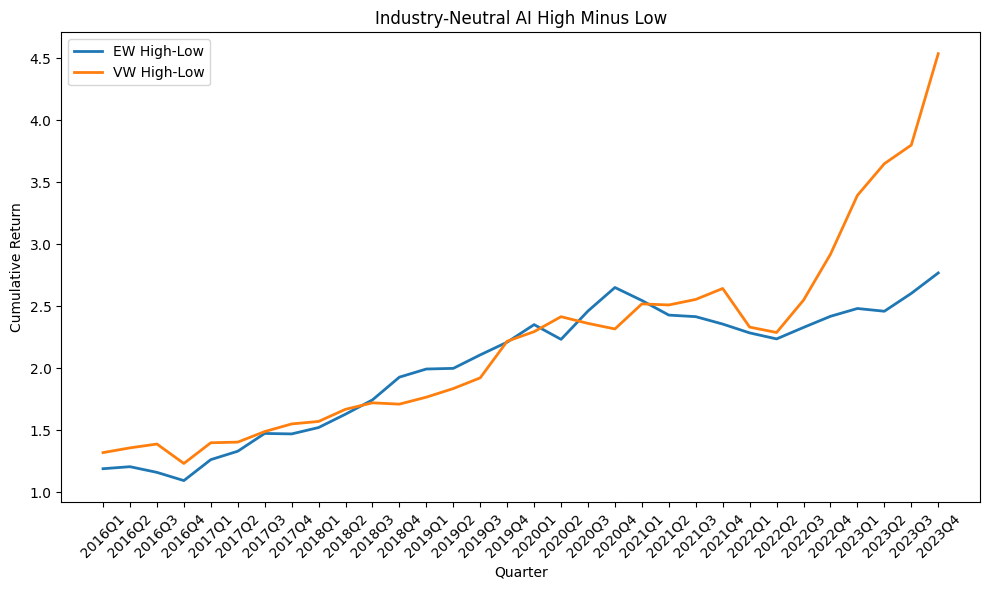

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(cum_ind_ew.index, cum_ind_ew['HML_AI_ind'], label='EW High-Low', linewidth=2)
plt.plot(cum_ind_vw.index, cum_ind_vw['HML_AI_ind'], label='VW High-Low', linewidth=2)
plt.title('Industry-Neutral AI High Minus Low')
plt.xlabel('Quarter')
plt.ylabel('Cumulative Return')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
model_ind_ew, df_reg_ind_ew, out_ind_ew = run_ff5(port_ind_ew, ff_q, "Equal-weighted", 'HML_AI_ind')
model_ind_vw, df_reg_ind_vw, out_ind_vw = run_ff5(port_ind_vw, ff_q, "Value-weighted", 'HML_AI_ind')


Equal-weighted FF5 regression
Sample size: 32
         coef_fmt    se_fmt      pval
const   0.0332***  (0.0087)  0.000137
Mkt-RF    -0.0278  (0.0813)  0.732117
SMB       -0.0566  (0.1959)  0.772857
HML       -0.2879  (0.2111)  0.172513
RMW       -0.2191  (0.2566)  0.393209
CMA        0.2820  (0.2574)  0.273167

Value-weighted FF5 regression
Sample size: 32
         coef_fmt    se_fmt      pval
const   0.0399***  (0.0109)  0.000239
Mkt-RF     0.0880  (0.1768)  0.618794
SMB        0.2123  (0.3464)  0.540012
HML       -0.3134  (0.3824)  0.412413
RMW        0.3890  (0.4450)  0.382081
CMA        0.0691  (0.4529)  0.878784


## Fama - MacBeth

In [ ]:
x_vars = [
    'z_log_mktcap',
    'z_bm_ratio',
    'z_leverage',
    'z_log_revenue',
    'z_log_rnd',
    'z_log_capex',
    'z_ai_score_composite'
]

df_fm = df_reg.copy()

# keep only needed columns
keep_cols = ['calendar_q', 'return_t1'] + x_vars
df_fm = df_fm[keep_cols].copy()

# force numeric
for col in ['return_t1'] + x_vars:
    df_fm[col] = pd.to_numeric(df_fm[col], errors='coerce')

# drop missing
df_fm = df_fm.dropna(subset=['return_t1'] + x_vars).copy()
df_fm['calendar_q'] = df_fm['calendar_q'].astype(str)

In [ ]:
betas = []

for q, g in df_fm.groupby('calendar_q'):
    if len(g) < 20:
        continue

    y = pd.to_numeric(g['return_t1'], errors='coerce').astype(float)
    X = g[x_vars].apply(pd.to_numeric, errors='coerce').astype(float)

    valid = y.notna() & X.notna().all(axis=1)
    y = y.loc[valid]
    X = X.loc[valid]

    if len(y) < 20:
        continue

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    betas.append(model.params)

betas_df = pd.DataFrame(betas)

In [ ]:
def nw_tstat_fm(series, lags=4):
    y = pd.to_numeric(series, errors='coerce').dropna().astype(float)
    X = np.ones(len(y))
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return model.params[0], model.tvalues[0], model.pvalues[0]

def add_stars_t(t):
    if abs(t) > 2.58:
        return '***'
    elif abs(t) > 1.96:
        return '**'
    elif abs(t) > 1.65:
        return '*'
    return ''

results = []
for col in betas_df.columns:
    coef, t_stat, pval = nw_tstat_fm(betas_df[col])
    results.append({
        'variable': col,
        'coef': coef,
        't_stat': t_stat,
        'p_value': pval
    })

fm_table = pd.DataFrame(results).set_index('variable')

/tmp/ipykernel_111128/3201293892.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return model.params[0], model.tvalues[0], model.pvalues[0]
/tmp/ipykernel_111128/3201293892.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return model.params[0], model.tvalues[0], model.pvalues[0]
/tmp/ipykernel_111128/3201293892.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return model.params[0], model.tvalues[0], model.pvalues[0]
/tmp

In [ ]:
fm_table['coef_fmt'] = fm_table['coef'].map(lambda x: f"{x:.4f}") + fm_table['t_stat'].apply(add_stars_t)
fm_table['t_fmt'] = fm_table['t_stat'].map(lambda x: f"({x:.2f})")

print("Number of quarters used:", len(betas_df))
print(fm_table[['coef_fmt', 't_fmt', 'p_value']])

Number of quarters used: 32
                        coef_fmt    t_fmt   p_value
variable                                           
const                  0.0485***   (3.43)  0.000607
z_log_mktcap          -0.0189***  (-4.38)  0.000012
z_bm_ratio               -0.0047  (-1.25)  0.210812
z_leverage               -0.0008  (-0.42)  0.676932
z_log_revenue             0.0073   (1.09)  0.275061
z_log_rnd                 0.0052   (1.39)  0.163445
z_log_capex               0.0015   (0.66)  0.511550
z_ai_score_composite    0.0068**   (1.96)  0.049890


## If high-AI firms (or AI HML portfolio) perform worse in bad states

In [ ]:
df_test_vw = port_ind_vw.reset_index().merge(ff_q, on='calendar_q', how='inner')

df_test_vw['bad_state'] = (df_test_vw['Mkt-RF'] < 0).astype(int)

y = df_test_vw['HML_AI_ind']

X = df_test_vw[['bad_state', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             HML_AI_ind   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                 -0.061
Method:                 Least Squares   F-statistic:                     3.059
Date:                Fri, 24 Apr 2026   Prob (F-statistic):             0.0220
Time:                        20:35:40   Log-Likelihood:                 36.664
No. Observations:                  32   AIC:                            -59.33
Df Residuals:                      25   BIC:                            -49.07
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0712      0.021      3.416      0.0

In [ ]:
df_test_ew = port_ind_ew.reset_index().merge(ff_q, on='calendar_q', how='inner')

df_test_ew['bad_state'] = (df_test_ew['Mkt-RF'] < 0).astype(int)

y = df_test_ew['HML_AI_ind']

X = df_test_ew[['bad_state', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             HML_AI_ind   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                 -0.035
Method:                 Least Squares   F-statistic:                     2.802
Date:                Fri, 24 Apr 2026   Prob (F-statistic):             0.0317
Time:                        20:35:40   Log-Likelihood:                 48.128
No. Observations:                  32   AIC:                            -82.26
Df Residuals:                      25   BIC:                            -72.00
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0527      0.011      4.997      0.0